# Laboratorio 4 — Limpieza y Preparación de Datos
**Curso:** Minería de Datos (EIN132A25)
**Dataset:** Pokémon (Gen 1–6)

## Objetivos
- Detectar y tratar **valores faltantes**
- Identificar y manejar **outliers**
- Convertir variables categóricas (**encoding**)
- Aplicar **normalización y estandarización**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# url = "https://gist.githubusercontent.com/armgilles/194bcff35001e7eb53a2a8b441e8b2c6/raw/92200bc0a673d5ce2110aaad4544ed6c4010f687/pokemon.csv"
url = 'pokemon.csv'
df = pd.read_csv(url)
print(f"Shape: {df.shape}")
df.head(10)

Shape: (800, 13)


,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
5,5,Charmeleon,Fire,NaN,405,58,64,58,80,65,80,1,False
6,6,Charizard,Fire,Flying,534,78,84,78,109,85,100,1,False
7,6,CharizardMega Charizard X,Fire,Dragon,634,78,130,111,130,85,100,1,False
8,6,CharizardMega Charizard Y,Fire,Flying,634,78,104,78,159,115,100,1,False
9,7,Squirtle,Water,NaN,314,44,48,65,50,64,43,1,False


In [2]:
print("Tipos de datos:")
print(df.dtypes)
print("\nEstadísticas básicas:")
df.describe()

Tipos de datos:
#             int64
Name            str
Type 1          str
Type 2          str
Total         int64
HP            int64
Attack        int64
Defense       int64
Sp. Atk       int64
Sp. Def       int64
Speed         int64
Generation    int64
Legendary      bool
dtype: object

Estadísticas básicas:


,#,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
count,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000
mean,362.813750,435.10250,69.258750,79.001250,73.842500,72.820000,71.902500,68.277500,3.32375
std,208.343798,119.96304,25.534669,32.457366,31.183501,32.722294,27.828916,29.060474,1.66129
min,1.000000,180.00000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.00000
25%,184.750000,330.00000,50.000000,55.000000,50.000000,49.750000,50.000000,45.000000,2.00000
50%,364.500000,450.00000,65.000000,75.000000,70.000000,65.000000,70.000000,65.000000,3.00000
75%,539.250000,515.00000,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000,5.00000
max,721.000000,780.00000,255.000000,190.000000,230.000000,194.000000,230.000000,180.000000,6.00000


## 1. Valores faltantes

### Detección

In [3]:
print('Valores faltantes por columna:')
print(df.isnull().sum())
print('\nPorcentaje de faltantes:')
print((df.isnull().mean() * 100).round(2))

Valores faltantes por columna:
#               0
Name            0
Type 1          0
Type 2        386
Total           0
HP              0
Attack          0
Defense         0
Sp. Atk         0
Sp. Def         0
Speed           0
Generation      0
Legendary       0
dtype: int64

Porcentaje de faltantes:
#              0.00
Name           0.00
Type 1         0.00
Type 2        48.25
Total          0.00
HP             0.00
Attack         0.00
Defense        0.00
Sp. Atk        0.00
Sp. Def        0.00
Speed          0.00
Generation     0.00
Legendary      0.00
dtype: float64


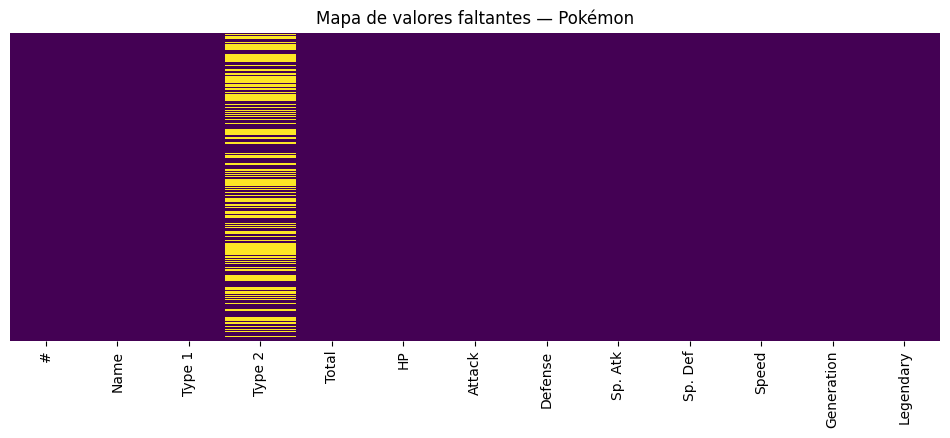

In [4]:
plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Mapa de valores faltantes — Pokémon")
plt.show()

### Estrategias de tratamiento

La columna `Type 2` tiene ~48% de valores faltantes, ya que no todos los Pokémon tienen un segundo tipo. Esto **no es un error** en los datos — es información válida. Lo correcto es imputar con la categoría `'None'`.

In [5]:
# Type 2 faltante → 'None' (pokémon mono-tipo)
df["Type 2"] = df["Type 2"].fillna("None")
print(f"Faltantes en 'Type 2' tras imputación: {df['Type 2'].isnull().sum()}")
print("\nDistribución de Type 2 (top 10):")
print(df["Type 2"].value_counts().head(10))

Faltantes en 'Type 2' tras imputación: 0

Distribución de Type 2 (top 10):
Type 2
None        386
Flying       97
Ground       35
Poison       34
Psychic      33
Fighting     26
Grass        25
Fairy        23
Steel        22
Dark         20
Name: count, dtype: int64


In [6]:
print('Valores faltantes tras tratamiento:')
print(df.isnull().sum())

Valores faltantes tras tratamiento:
#             0
Name          0
Type 1        0
Type 2        0
Total         0
HP            0
Attack        0
Defense       0
Sp. Atk       0
Sp. Def       0
Speed         0
Generation    0
Legendary     0
dtype: int64


## 2. Outliers — Detección con IQR

Los Pokémon legendarios suelen tener estadísticas extremas. Vamos a analizar el `Total` de stats.

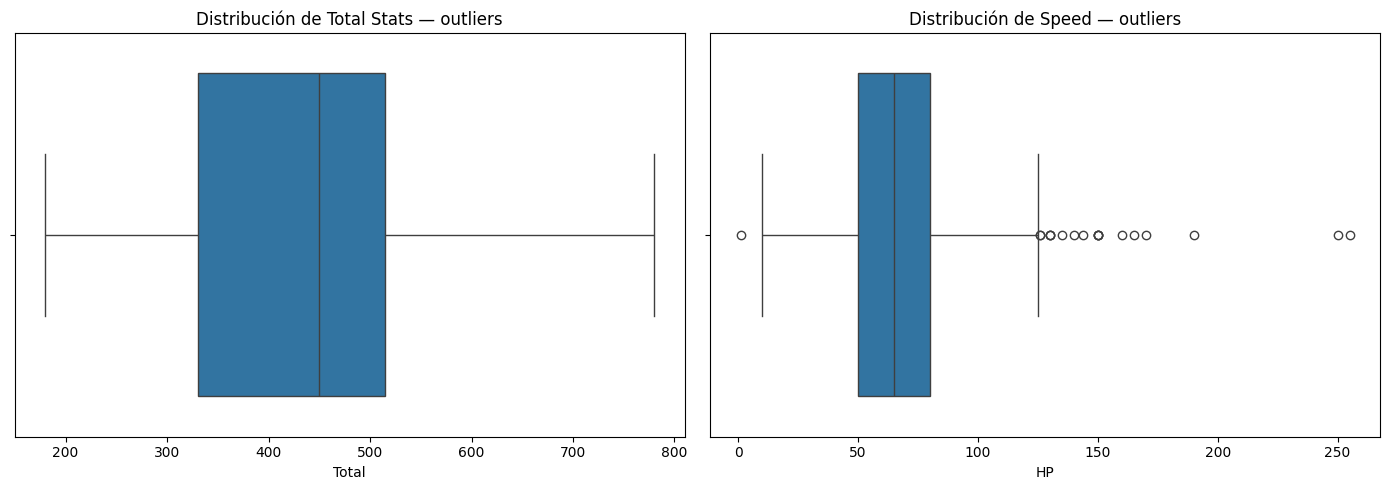

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x=df["Total"], ax=axes[0])
axes[0].set_title("Distribución de Total Stats — outliers")

sns.boxplot(x=df["HP"], ax=axes[1])
axes[1].set_title("Distribución de Speed — outliers")

plt.tight_layout()
plt.show()

50.0
80.0
45.0
125.0


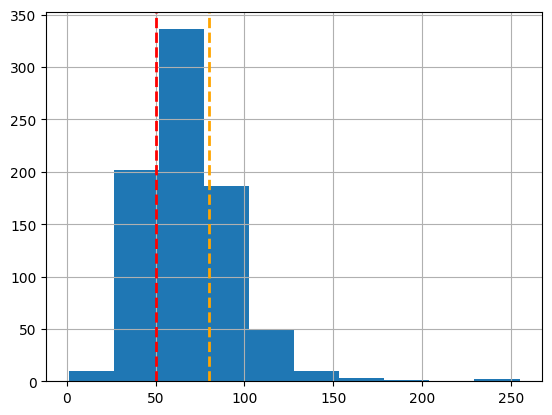

In [8]:
col = "HP"
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR
limite_inferior = Q1 - 1.5*IQR
print(Q1)
print(Q3)
print(1.5*IQR)
print(limite_superior)
# df[df['HP'] > limite_superior]
# df[df['HP'] < limite_inferior]


fig, ax = plt.subplots()
df[col].hist(ax=ax)
# Agregar 3 líneas verticales
ax.axvline(x=Q1, color='red', linestyle='--', linewidth=2)
ax.axvline(x=Q3, color='orange', linestyle='--', linewidth=2)

In [9]:
Q1 = df["Total"].quantile(0.25)
Q3 = df["Total"].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

outliers = df[df["Total"] > limite_superior]
print(f"Outliers detectados (Total > {limite_superior:.0f}): {len(outliers)}")
print(outliers[["Name", "Type 1", "Total", "Legendary"]].head(10))

Outliers detectados (Total > 792): 0
Empty DataFrame
Columns: [Name, Type 1, Total, Legendary]
Index: []


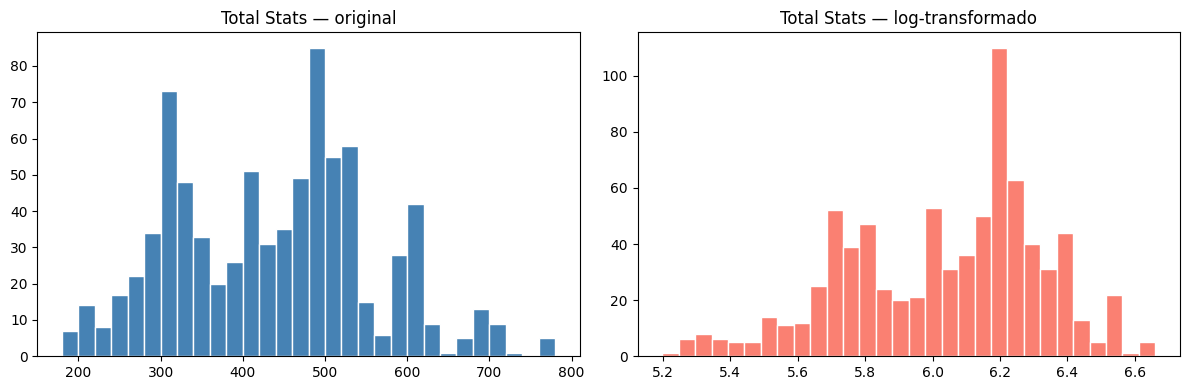

In [10]:
# Transformación logarítmica para reducir sesgo
df["Total_log"] = np.log1p(df["Total"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["Total"], bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Total Stats — original")
axes[1].hist(df["Total_log"], bins=30, color="salmon", edgecolor="white")
axes[1].set_title("Total Stats — log-transformado")
plt.tight_layout()
plt.show()

## 3. Encoding de variables categóricas

### Label Encoding — Type 1

In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Type1_encoded"] = le.fit_transform(df["Type 1"])
print("Clases y su código:")
for i, cls in enumerate(le.classes_):
    print(f"  {i:2d} --> {cls}")

Clases y su código:
   0 --> Bug
   1 --> Dark
   2 --> Dragon
   3 --> Electric
   4 --> Fairy
   5 --> Fighting
   6 --> Fire
   7 --> Flying
   8 --> Ghost
   9 --> Grass
  10 --> Ground
  11 --> Ice
  12 --> Normal
  13 --> Poison
  14 --> Psychic
  15 --> Rock
  16 --> Steel
  17 --> Water


In [12]:
# Encoding booleano de Legendary
df["Legendary_int"] = df["Legendary"].astype(int)
print(f"Pokémon legendarios: {df['Legendary_int'].sum()} de {len(df)}")
print(df[["Name", "Legendary", "Legendary_int"]].head())

Pokémon legendarios: 65 de 800
                    Name  Legendary  Legendary_int
0              Bulbasaur      False              0
1                Ivysaur      False              0
2               Venusaur      False              0
3  VenusaurMega Venusaur      False              0
4             Charmander      False              0


### One-Hot Encoding — Generation

In [13]:
gen_dummies = pd.get_dummies(df["Generation"], prefix="Gen")
print(gen_dummies.head())

df = pd.concat([df, gen_dummies], axis=1)
print(f"Columnas tras OHE de Generation: {[c for c in df.columns if c.startswith('Gen_')]}")

   Gen_1  Gen_2  Gen_3  Gen_4  Gen_5  Gen_6
0   True  False  False  False  False  False
1   True  False  False  False  False  False
2   True  False  False  False  False  False
3   True  False  False  False  False  False
4   True  False  False  False  False  False
Columnas tras OHE de Generation: ['Gen_1', 'Gen_2', 'Gen_3', 'Gen_4', 'Gen_5', 'Gen_6']


In [25]:
for gen in range(1,7):
    df[f'Gen_{gen}'] = df[f'Gen_{gen}'].astype(int)

In [26]:
df

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,...,Legendary,Total_log,Type1_encoded,Legendary_int,Gen_1,Gen_2,Gen_3,Gen_4,Gen_5,Gen_6
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,...,False,5.765191,9,0,1,0,0,0,0,0
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,...,False,6.006353,9,0,1,0,0,0,0,0
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,...,False,6.265301,9,0,1,0,0,0,0,0
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,...,False,6.439350,9,0,1,0,0,0,0,0
4,4,Charmander,Fire,None,309,39,52,43,60,50,...,False,5.736572,6,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,719,Diancie,Rock,Fairy,600,50,100,150,100,150,...,True,6.398595,15,1,0,0,0,0,0,1
796,719,DiancieMega Diancie,Rock,Fairy,700,50,160,110,160,110,...,True,6.552508,15,1,0,0,0,0,0,1
797,720,HoopaHoopa Confined,Psychic,Ghost,600,80,110,60,150,130,...,True,6.398595,14,1,0,0,0,0,0,1
798,720,HoopaHoopa Unbound,Psychic,Dark,680,80,160,60,170,130,...,True,6.523562,14,1,0,0,0,0,0,1


## 4. Normalización y Estandarización

Las estadísticas de combate (HP, Ataque, Defensa, etc.) tienen escalas diferentes. Vamos a normalizarlas.

In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

stats_cols = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]

# agregar comentarios de entre que valores quedan y porque
scaler_minmax = MinMaxScaler()
df[[f"{c}_norm" for c in stats_cols]] = scaler_minmax.fit_transform(df[stats_cols])

# agregar comentarios de entre que valores quedan y porque
scaler_std = StandardScaler()
df[[f"{c}_std" for c in stats_cols]] = scaler_std.fit_transform(df[stats_cols])

print("Estadísticas — valores originales vs normalizados:")
df[["HP", "HP_norm", "HP_std", "Speed", "Speed_norm", "Speed_std"]].describe().round(3)

Estadísticas — valores originales vs normalizados:


,HP,HP_norm,HP_std,Speed,Speed_norm,Speed_std
count,800.000,800.000,800.000,800.000,800.000,800.000
mean,69.259,0.269,-0.000,68.278,0.362,-0.000
std,25.535,0.101,1.001,29.060,0.166,1.001
min,1.000,0.000,-2.675,5.000,0.000,-2.179
25%,50.000,0.193,-0.755,45.000,0.229,-0.802
50%,65.000,0.252,-0.167,65.000,0.343,-0.113
75%,80.000,0.311,0.421,90.000,0.486,0.748
max,255.000,1.000,7.279,180.000,1.000,3.847


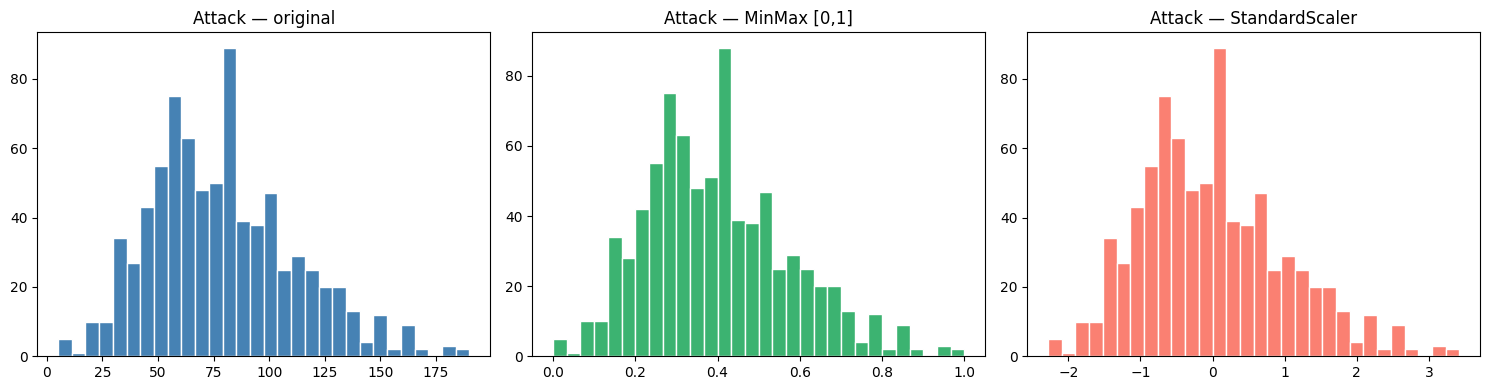

In [28]:
# Visualización comparativa
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(df["Attack"], bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Attack — original")
axes[1].hist(df["Attack_norm"], bins=30, color="mediumseagreen", edgecolor="white")
axes[1].set_title("Attack — MinMax [0,1]")
axes[2].hist(df["Attack_std"], bins=30, color="salmon", edgecolor="white")
axes[2].set_title("Attack — StandardScaler")
plt.tight_layout()
plt.show()

## 5. Ejercicios

### Ejercicio 1 — Reporte de faltantes

In [ ]:
# Cargar el dataset original y reportar faltantes por columna

In [ ]:
# Cargar el dataset original y reportar faltantes por columna
df_original = pd.read_csv(url)
faltantes = df_original.isnull().sum()
pct = (df_original.isnull().mean() * 100).round(2)
reporte = pd.DataFrame({"Faltantes": faltantes, "Porcentaje (%)": pct})
print(reporte[reporte["Faltantes"] > 0])

### Ejercicio 2 — Outliers en Attack y Sp. Attack

In [ ]:
# Detectar outliers en Attack y Sp. Attack con el método IQR y listar los pokémon afectados

In [ ]:
# Detectar outliers en Attack con el método IQR y listar los pokémon afectados
Q1_hp = df_original["Attack"].quantile(0.25)
Q3_hp = df_original["Attack"].quantile(0.75)
IQR_hp = Q3_hp - Q1_hp
lim_sup_hp = Q3_hp + 1.5 * IQR_hp

outliers_hp = df_original[df_original["Attack"] > lim_sup_hp]
print(f"Outliers en Attack (>{lim_sup_hp:.0f}): {len(outliers_hp)}")
print(outliers_hp[["Name", "Attack", "Type 1", "Legendary"]].sort_values("Attack", ascending=False).head(10))

### Ejercicio 3 — Escalar las 6 estadísticas de combate

In [ ]:
# Escalar HP, Attack, Defense, Sp. Atk, Sp. Def, Speed con StandardScaler
# y verificar que la media sea ~0 y la desviación estándar sea ~1

In [ ]:
# Escalar HP, Attack, Defense, Sp. Atk, Sp. Def, Speed con StandardScaler
# y verificar que la media sea ~0 y la desviación estándar sea ~1
from sklearn.preprocessing import StandardScaler

stats = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]
sc = StandardScaler()
scaled = sc.fit_transform(df_original[stats])

print("Media por columna (debe ser ~0):")
print(dict(zip(stats, scaled.mean(axis=0).round(6))))
print("\nDesv. estándar (debe ser ~1):")
print(dict(zip(stats, scaled.std(axis=0).round(6))))

### Desafío — Pipeline de limpieza completo

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

def pipeline_limpieza_pokemon(df_raw):
    df_preprocessed = df_raw.copy()
    # Hacer todas las magias
    return df_preprocessed

In [ ]:
# from sklearn.preprocessing import StandardScaler, LabelEncoder

# def pipeline_limpieza_pokemon(df_raw):
#     df_clean = df_raw.copy()

#     # 1. Valores faltantes
#     df_clean["Type 2"] = df_clean["Type 2"].fillna("None")

#     # 2. Eliminar columnas no útiles
#     df_clean = df_clean.drop(columns=["#", "Name"])

#     # 3. Encoding
#     le = LabelEncoder()
#     df_clean["Type1_enc"] = le.fit_transform(df_clean["Type 1"])
#     df_clean["Type2_enc"] = le.fit_transform(df_clean["Type 2"])
#     df_clean["Legendary"] = df_clean["Legendary"].astype(int)
#     df_clean = df_clean.drop(columns=["Type 1", "Type 2"])

#     # 4. Scaling de estadísticas
#     stats_cols = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed", "Total"]
#     sc = StandardScaler()
#     df_clean[stats_cols] = sc.fit_transform(df_clean[stats_cols])

#     return df_clean

# df_listo = pipeline_limpieza_pokemon(pd.read_csv(url))
# print(f"Shape final: {df_listo.shape}")
# print(f"Faltantes: {df_listo.isnull().sum().sum()}")
# df_listo.head()